# simple softmax

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [6]:
import PatnaikPearson as pp
import cupy

In [4]:
num_values = 100
these_nu_over_d = np.arange(1,num_values + 1, 1.0)/ (num_values + 1.0)
print(these_nu_over_d)

[0.00990099 0.01980198 0.02970297 0.03960396 0.04950495 0.05940594
 0.06930693 0.07920792 0.08910891 0.0990099  0.10891089 0.11881188
 0.12871287 0.13861386 0.14851485 0.15841584 0.16831683 0.17821782
 0.18811881 0.1980198  0.20792079 0.21782178 0.22772277 0.23762376
 0.24752475 0.25742574 0.26732673 0.27722772 0.28712871 0.2970297
 0.30693069 0.31683168 0.32673267 0.33663366 0.34653465 0.35643564
 0.36633663 0.37623762 0.38613861 0.3960396  0.40594059 0.41584158
 0.42574257 0.43564356 0.44554455 0.45544554 0.46534653 0.47524752
 0.48514851 0.4950495  0.5049505  0.51485149 0.52475248 0.53465347
 0.54455446 0.55445545 0.56435644 0.57425743 0.58415842 0.59405941
 0.6039604  0.61386139 0.62376238 0.63366337 0.64356436 0.65346535
 0.66336634 0.67326733 0.68316832 0.69306931 0.7029703  0.71287129
 0.72277228 0.73267327 0.74257426 0.75247525 0.76237624 0.77227723
 0.78217822 0.79207921 0.8019802  0.81188119 0.82178218 0.83168317
 0.84158416 0.85148515 0.86138614 0.87128713 0.88118812 0.89108

In [21]:
# combine these sets
arr1 = np.arange(0.001, 0.04, 0.001) # 50
arr2 = np.arange(0.04, 0.06, 0.002) # 10
arr3 = np.arange(0.06, 0.1, 0.005) # 10
arr4 = np.arange(0.1, 0.2, 0.1) # 16
arr5 = np.arange(0.2, 1.0, 0.05) # 40
combined = np.unique(np.concatenate((arr1, arr2)))
combined = np.unique(np.concatenate((combined, arr3)))
combined = np.unique(np.concatenate((combined, arr4)))
combined = np.unique(np.concatenate((combined, arr5)))

print(combined)
print(len(combined))

[0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011 0.012
 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022 0.023 0.024
 0.025 0.026 0.027 0.028 0.029 0.03  0.031 0.032 0.033 0.034 0.035 0.036
 0.037 0.038 0.039 0.04  0.042 0.044 0.046 0.048 0.05  0.052 0.054 0.056
 0.058 0.06  0.065 0.07  0.075 0.08  0.085 0.09  0.095 0.1   0.1   0.2
 0.25  0.3   0.35  0.4   0.45  0.5   0.55  0.6   0.65  0.7   0.75  0.8
 0.85  0.9   0.95 ]
75


In [28]:
# combine these sets
arr1 = np.arange(0.0005, 0.04, 0.0005) # 50
arr2 = np.arange(0.04, 0.1, 0.02) # 10
arr3 = np.arange(0.1, 1.0, 0.1) # 10
#arr4 = np.arange(0.1, 0.2, 0.1) # 16
#arr5 = np.arange(0.2, 1.0, 0.05) # 40
combined = np.unique(np.concatenate((arr1, arr2)))
combined = np.unique(np.concatenate((combined, arr3)))
#combined = np.unique(np.concatenate((combined, arr4)))
#combined = np.unique(np.concatenate((combined, arr5)))

print(combined)
print(len(combined))

[5.00e-04 1.00e-03 1.50e-03 2.00e-03 2.50e-03 3.00e-03 3.50e-03 4.00e-03
 4.50e-03 5.00e-03 5.50e-03 6.00e-03 6.50e-03 7.00e-03 7.50e-03 8.00e-03
 8.50e-03 9.00e-03 9.50e-03 1.00e-02 1.05e-02 1.10e-02 1.15e-02 1.20e-02
 1.25e-02 1.30e-02 1.35e-02 1.40e-02 1.45e-02 1.50e-02 1.55e-02 1.60e-02
 1.65e-02 1.70e-02 1.75e-02 1.80e-02 1.85e-02 1.90e-02 1.95e-02 2.00e-02
 2.05e-02 2.10e-02 2.15e-02 2.20e-02 2.25e-02 2.30e-02 2.35e-02 2.40e-02
 2.45e-02 2.50e-02 2.55e-02 2.60e-02 2.65e-02 2.70e-02 2.75e-02 2.80e-02
 2.85e-02 2.90e-02 2.95e-02 3.00e-02 3.05e-02 3.10e-02 3.15e-02 3.20e-02
 3.25e-02 3.30e-02 3.35e-02 3.40e-02 3.45e-02 3.50e-02 3.55e-02 3.60e-02
 3.65e-02 3.70e-02 3.75e-02 3.80e-02 3.85e-02 3.90e-02 3.95e-02 4.00e-02
 6.00e-02 8.00e-02 1.00e-01 2.00e-01 3.00e-01 4.00e-01 5.00e-01 6.00e-01
 7.00e-01 8.00e-01 9.00e-01]
91


In [29]:
#these_alphas = combined #np.arange(0.05,2.05,0.05)
#num_values = len(these_alphas)

#num_values = 100
these_nu_over_d = combined # np.arange(1,num_values + 1, 1.0)/ (num_values + 1.0)
num_values = len(these_nu_over_d)

scale_factor = 500

alpha_vals = np.zeros(num_values)
implied_alpha_W_vals = np.zeros(num_values)
implied_alpha_softmaxW = np.zeros(num_values)
actual_nu_W_over_d_vals = np.zeros(num_values)
actual_alpha_softmaxW_vals = np.zeros(num_values)
estimated_alpha_softmaxW_vals = np.zeros(num_values)
actual_nu_softmaxW_over_d_vals = np.zeros(num_values)
implied_nu_softmaxW_over_d_vals = np.zeros(num_values)

uniform_draws = True
use_pareto = True
use_uniform = False
use_cauchy = False
verbose = False

i = 0
for nu_over_d in these_nu_over_d: 

  d = int(scale_factor * (1.0 + np.random.uniform(0,1)))
  this_alpha = pp.calculate_alpha_given_nu_over_d_and_d(nu_over_d, d)
  print(i, ", d = ", d, ", nu_over_d = ", nu_over_d, ", this_alpha = ", this_alpha)
  alpha_vals[i] = this_alpha

  W = pp.generate_square_weight_matrix(d, this_alpha, uniform_draws, use_pareto, use_uniform, use_cauchy, verbose)

  actual_nu_W_over_d = pp.calculate_PatnaikPearson_dim(W) / d
  actual_nu_W_over_d_vals[i] = actual_nu_W_over_d

  implied_alpha_W = pp.calculate_alpha_given_nu_over_d_and_d(actual_nu_W_over_d, d)
  implied_alpha_W_vals[i] = implied_alpha_W

  softmaxW = pp.row_wise_softmax(W / math.sqrt(d))

  actual_nu_softmaxW_over_d = pp.calculate_PatnaikPearson_dim(softmaxW) / d
  actual_nu_softmaxW_over_d_vals[i] = actual_nu_softmaxW_over_d

  actual_alpha_softmaxW = pp.calculate_alpha_given_nu_over_d_and_d(actual_nu_softmaxW_over_d, d)
  actual_alpha_softmaxW_vals[i] = actual_alpha_softmaxW

  estimated_alpha_softmaxW = pp.calculate_softmax_alpha(implied_alpha_W)
  estimated_alpha_softmaxW_vals[i] = estimated_alpha_softmaxW

  implied_nu_softmaxW_over_d = pp.calculate_nu_over_d_given_alpha_and_d(estimated_alpha_softmaxW, d)
  implied_nu_softmaxW_over_d_vals[i] = implied_nu_softmaxW_over_d

  print(i, "this_alpha = ", this_alpha)
  print(i, "implied_alpha_W = ", implied_alpha_W)
  print(i, "actual_alpha_softmaxW = ", actual_alpha_softmaxW)
  print(i, "estimated_alpha_softmaxW = ", estimated_alpha_softmaxW)
  print(i, "actual_nu_W_over_d = ", actual_nu_W_over_d)
  print(i, "actual_nu_softmaxW_over_d = ", actual_nu_softmaxW_over_d)
  print(i, "implied_nu_softmaxW_over_d = ", implied_nu_softmaxW_over_d)
    
  i +=1

0 , d =  847 , nu_over_d =  0.0005 , this_alpha =  0.16185094273731213
 ** generate_square_weight_matrix: using GPU **
 ** calculate_softmax_alpha : need to re-do hardcoded values ** 
** get_alpha_vals_softmax_alpha_vals : need to recalculate for new alpha **
0 this_alpha =  0.16185094273731213
0 implied_alpha_W =  0.29821578308333185
0 actual_alpha_softmaxW =  0.45502771689557214
0 estimated_alpha_softmaxW =  0.4519925462888703
0 actual_nu_W_over_d =  0.0012165899153708775
0 actual_nu_softmaxW_over_d =  0.002792902160561397
0 implied_nu_softmaxW_over_d =  0.0027491792264439426
1 , d =  584 , nu_over_d =  0.001 , this_alpha =  0.20544791501271792
 ** generate_square_weight_matrix: using GPU **
 ** calculate_softmax_alpha : need to re-do hardcoded values ** 
** get_alpha_vals_softmax_alpha_vals : need to recalculate for new alpha **
1 this_alpha =  0.20544791501271792
1 implied_alpha_W =  0.30700709581298097
1 actual_alpha_softmaxW =  0.6274254452413853
1 estimated_alpha_softmaxW =  0.5

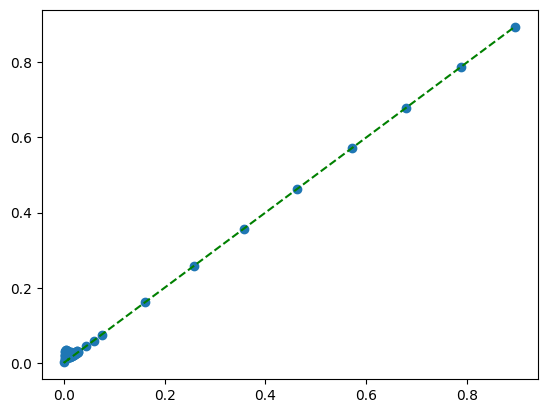

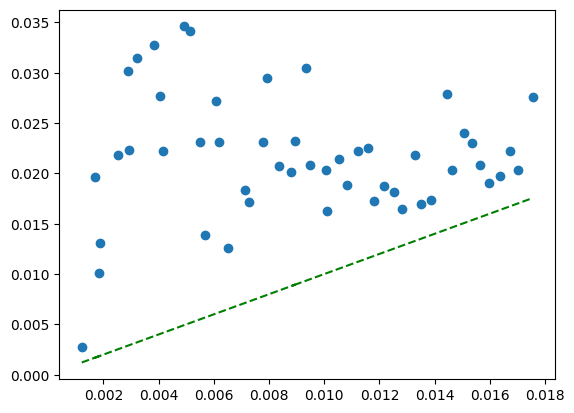

In [30]:
plt.plot(actual_nu_W_over_d_vals, actual_nu_W_over_d_vals, color = "green", linestyle = "--", label = "nu/d (W)")
plt.scatter(actual_nu_W_over_d_vals, actual_nu_softmaxW_over_d_vals)
plt.show()

k = 50
plt.plot(actual_nu_W_over_d_vals[0:k], actual_nu_W_over_d_vals[0:k], color = "green", linestyle = "--", label = "nu/d (W)")
plt.scatter(actual_nu_W_over_d_vals[0:k], actual_nu_softmaxW_over_d_vals[0:k])
plt.show()

In [31]:
smoothed_nu_softmaxW_over_d_vals = pp.smooth_this_array(actual_nu_softmaxW_over_d_vals, smoothing_window_length = 10, num_decimal_places = 6)

[1. 2. 3. 4. 5. 5. 4. 3. 2. 1.]
[0.03333333 0.06666667 0.1        0.13333333 0.16666667 0.16666667
 0.13333333 0.1        0.06666667 0.03333333]


In [111]:
smoothed_nu_softmaxW_over_d_vals = actual_nu_W_over_d_vals + this_vec_softmax_f(actual_nu_W_over_d_vals)

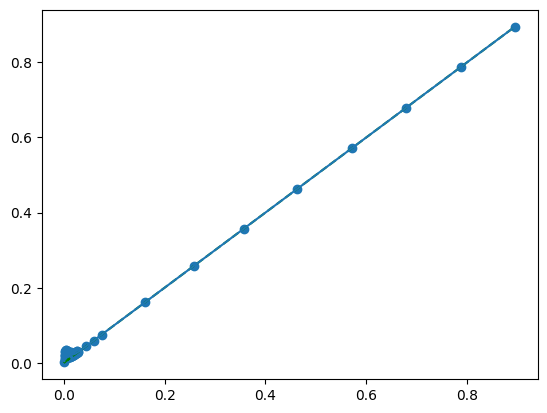

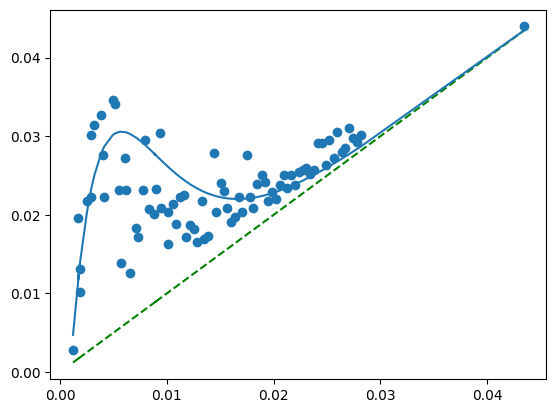

In [112]:
plt.plot(actual_nu_W_over_d_vals, actual_nu_W_over_d_vals, color = "green", linestyle = "--", label = "nu/d (W)")
plt.scatter(actual_nu_W_over_d_vals, actual_nu_softmaxW_over_d_vals)
plt.plot(actual_nu_W_over_d_vals, smoothed_nu_softmaxW_over_d_vals)
plt.show()

k = 81
plt.plot(actual_nu_W_over_d_vals[0:k], actual_nu_W_over_d_vals[0:k], color = "green", linestyle = "--", label = "nu/d (W)")
plt.scatter(actual_nu_W_over_d_vals[0:k], actual_nu_softmaxW_over_d_vals[0:k])
plt.plot(actual_nu_W_over_d_vals[0:k], smoothed_nu_softmaxW_over_d_vals[0:k])
plt.show()

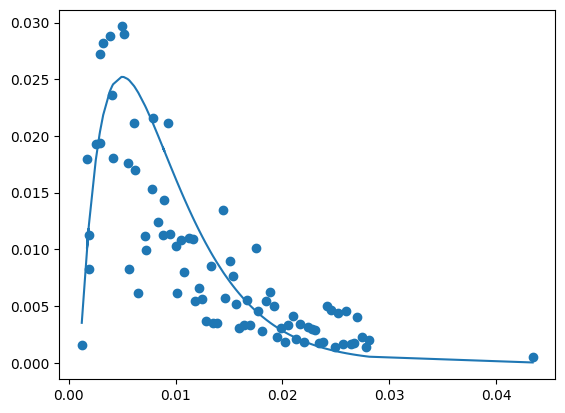

In [110]:
diff_vals = actual_nu_softmaxW_over_d_vals - actual_nu_W_over_d_vals

approx_vals = this_vec_softmax_f(actual_nu_W_over_d_vals)

k = 81
plt.scatter(actual_nu_W_over_d_vals[0:k], diff_vals[0:k])
plt.plot(actual_nu_W_over_d_vals[0:k], approx_vals[0:k])
plt.show()

In [109]:
def softmax_f(x):
    a = 22.0
    b = -250.0
    c = 0.001
    fx = a * (x - c) * math.exp(b * x)
    return fx

# Apply the function using np.vectorize
this_vec_softmax_f = np.vectorize(softmax_f)